In [1]:
import pandas as pd
import numpy as np

# Creating a professional credit dataset
np.random.seed(42)
n_rows = 5000

data = {
    'Applicant_ID': range(1001, 1001 + n_rows),
    'Age': np.random.randint(18, 70, n_rows),
    'Annual_Income': np.random.randint(20000, 150000, n_rows),
    'Loan_Amount': np.random.randint(5000, 50000, n_rows),
    'Credit_Score': np.random.randint(300, 850, n_rows),
    'Employment_Years': np.random.randint(0, 40, n_rows),
    'Has_Prior_Default': np.random.choice([0, 1], n_rows, p=[0.9, 0.1]),
    'Default_Status': np.random.choice([0, 1], n_rows, p=[0.85, 0.15]) # 1 = Default
}

df = pd.DataFrame(data)
df.to_csv('credit_risk_data.csv', index=False)
print("Success: 'credit_risk_data.csv' created locally!")

Success: 'credit_risk_data.csv' created locally!


In [2]:
# Cell 2: Preprocessing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('credit_risk_data.csv')

# 1. Feature Engineering: Debt-to-Income Ratio
df['DTI_Ratio'] = df['Loan_Amount'] / df['Annual_Income']

# 2. Select Features
X = df[['Age', 'Annual_Income', 'Loan_Amount', 'Credit_Score', 'Employment_Years', 'DTI_Ratio', 'Has_Prior_Default']]
y = df['Default_Status']

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Scaling (Important for professional models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Prepared for Modeling.")

Data Prepared for Modeling.


In [3]:
# Cell 3: Training
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Using class_weight='balanced' because defaults are rare (Imbalanced Data)
model = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]):.4f}")

              precision    recall  f1-score   support

           0       0.85      0.95      0.90       848
           1       0.09      0.03      0.04       152

    accuracy                           0.81      1000
   macro avg       0.47      0.49      0.47      1000
weighted avg       0.73      0.81      0.77      1000

ROC-AUC Score: 0.4587


C:\Users\panka\AppData\Local\Temp\ipykernel_5288\2500698290.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


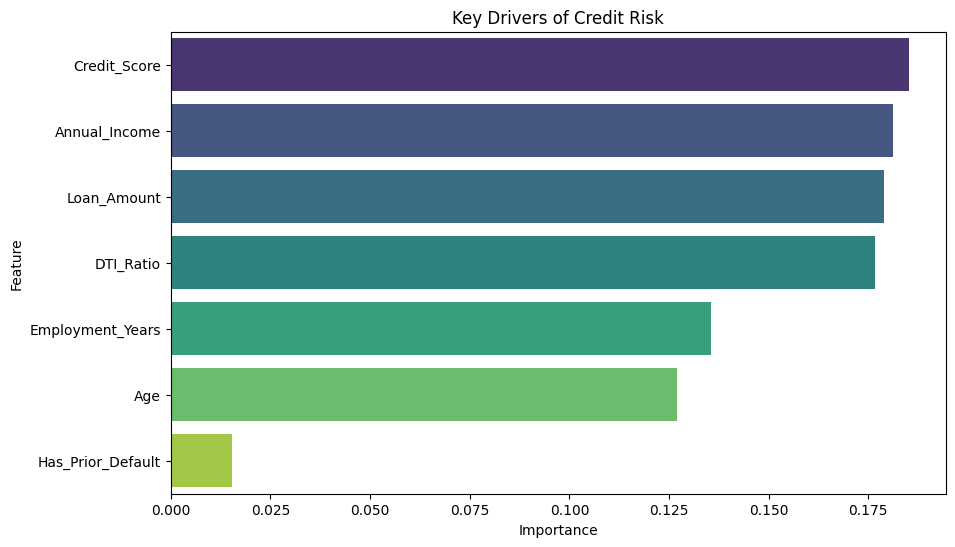

In [4]:
# Cell 4: Feature Importance Plot
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Key Drivers of Credit Risk')
plt.show()